In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from pyproj import Proj, Transformer
from scipy.interpolate import griddata
import xeofs as xe
from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import cartopy.crs as ccrs

crs = ccrs.PlateCarree()
import warnings
import os

warnings.filterwarnings('ignore')
from matplotlib.ticker import MultipleLocator


In [3]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/Data/'
path_ds = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'

# ice_vel_ds = xr.open_dataset(path + 'ice_vels_no_nan_ds.nc')
ice_vels_ds_melt_and_mean = xr.open_dataset(path + 'ice_vels_ds_melt_and_mean.nc')
#dot_masked_ds = xr.open_dataset(path_ds + 'dot_masked.nc')
ssh_regridded_ds = xr.open_dataset(path + 'regridded_ssh2icevel_ds.nc')
bedmap3 = xr.open_dataset(path_ds + 'bedmap3.nc')



In [4]:
print(ssh_regridded_ds['SSH_regridded'].shape)
print(ssh_regridded_ds['time'][2])
print(ssh_regridded_ds['time'][-1])

(61, 2916, 2916)
<xarray.DataArray 'time' ()> Size: 8B
array('2003-03-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2003-03-01
<xarray.DataArray 'time' ()> Size: 8B
array('2017-09-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2017-09-01


In [5]:
print(ice_vels_ds_melt_and_mean['melt'].isel(time=6))

<xarray.DataArray 'melt' (y: 2916, x: 2916)> Size: 34MB
[8503056 values with dtype=float32]
Coordinates:
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
    time     datetime64[ns] 8B 2004-09-01
Dimensions without coordinates: y, x


In [54]:
print(ice_vels_ds_melt_and_mean['melt_ann_mean'])

<xarray.DataArray 'melt_ann_mean' (time_ann: 15, y: 2916, x: 2916)> Size: 510MB
[127545840 values with dtype=float32]
Coordinates:
    lat       (y, x) float64 68MB -54.59 -54.61 -54.62 ... -54.62 -54.61 -54.59
    lon       (y, x) float64 68MB -135.0 -135.0 -135.0 ... 44.96 44.98 45.0
  * time_ann  (time_ann) <U29 2kB '2003-01-01T00:00:00.000000000' ... '2017-0...
Dimensions without coordinates: y, x


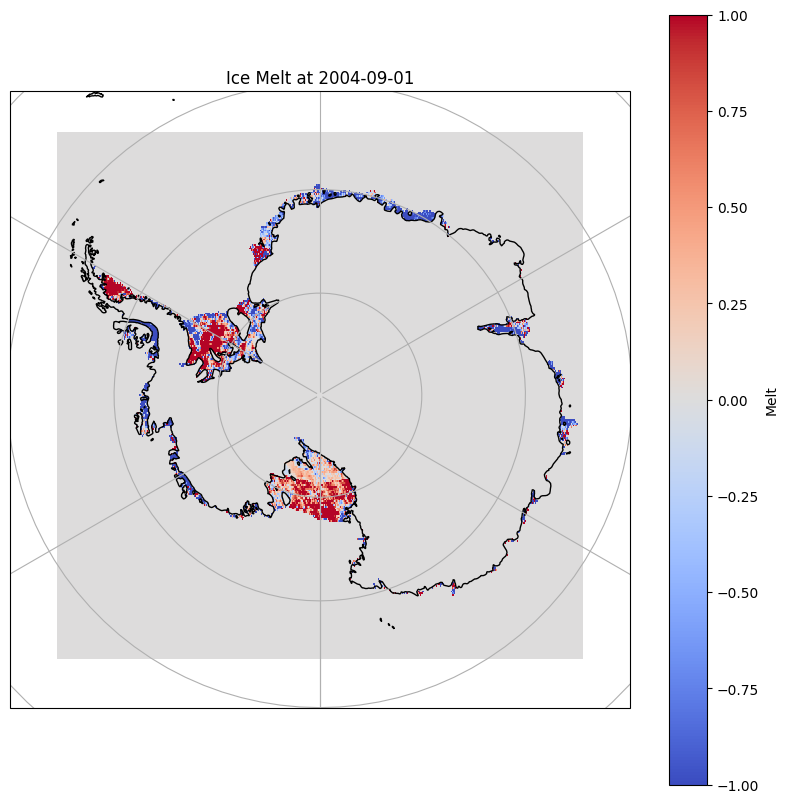

In [49]:
# Extract data from each dataset

%matplotlib inline

'''
[::10] this is to plot every 10th datapoint to make it easier to select the different ice sheets when i plot below
'''

data_1 = ice_vels_ds_melt_and_mean['melt'].isel(time=6)[::10]
lat_1 = ice_vels_ds_melt_and_mean['lat'][::10]
lon_1 = ice_vels_ds_melt_and_mean['lon'][::10]

# Create the figure and axes for subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})


# Plot 1: Ice Melt
ax1 = axes
ax1.coastlines()
ax1.gridlines(draw_labels=False)
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
mesh_1 = ax1.pcolormesh(lon_1, lat_1, data_1, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto', vmin=-1, vmax=1)
ax1.set_title("Ice Melt at 2004-09-01")
plt.colorbar(mesh_1, ax=ax1, orientation='vertical', label='Melt')

In [7]:
print(bedmap3.keys)

<bound method Mapping.keys of <xarray.Dataset> Size: 5GB
Dimensions:                 (x: 13334, y: 13334)
Coordinates:
  * x                       (x) float32 53kB -3.333e+06 -3.333e+06 ... 3.333e+06
  * y                       (y) float32 53kB 3.333e+06 3.333e+06 ... -3.333e+06
Data variables:
    surface_topography      (y, x) float32 711MB ...
    bed_uncertainty         (y, x) float32 711MB ...
    bed_topography          (y, x) float32 711MB ...
    mask                    (y, x) float32 711MB ...
    ice_thickness           (y, x) float32 711MB ...
    thickness_survey_count  (y, x) float32 711MB ...
    thickness_uncertainty   (y, x) float32 711MB ...
    mapping                 <U19 76B ...
Attributes: (12/26)
    crs:                    EPSG:3031
    title:                  BEDMAP3 - Ice thickness, bed and surface elevatio...
    summary:                We present here Bedmap3, the latest suite of grid...
    keywords:               Antarctica,BEDMAP,Elevation,Ice thickness
  

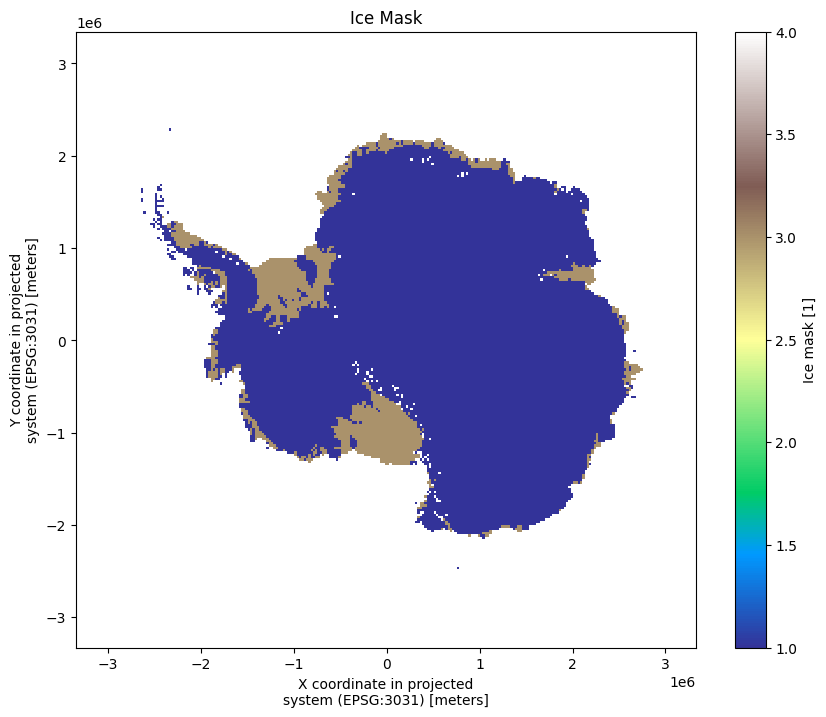

In [23]:
import xarray as xr
import matplotlib.pyplot as plt

%matplotlib inline

# Load dataset
ds = xr.open_dataset("bedmap3.nc")

# Subset or downsample (e.g., every 10th point)
bed = ds['mask'][::50, ::50]

# Plot
plt.figure(figsize=(10, 8))
bed.plot(cmap='terrain')
plt.title('Ice Mask')
plt.show()


In [50]:
''''

this script is to create an interactive map of the ice vel data which i can then use to create different polygons for each ice sheet and then use these to mask the data before averaging it and performing linear regression against SSH data

'''

import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
import numpy as np


%matplotlib tk

class PolygonExtentDrawer:
    def __init__(self, ax):
        self.ax = ax
        self.selector = PolygonSelector(ax, self.onselect)
        self.verts = []

    def onselect(self, verts):
        self.verts = verts
        xs, ys = zip(*verts)
        extent = {
            "lon_min": min(xs),
            "lon_max": max(xs),
            "lat_min": min(ys),
            "lat_max": max(ys)
        }
        print("\n Polygon Extents (Bounding Box):")
        print(f"Longitude: {extent['lon_min']:.2f} to {extent['lon_max']:.2f}")
        print(f"Latitude:  {extent['lat_min']:.2f} to {extent['lat_max']:.2f}")
        self.draw_polygon()

    def draw_polygon(self):
        x, y = zip(*self.verts)
        self.ax.plot(x + (x[0],), y + (y[0],), 'r--', lw=2)
        plt.draw()

# ---------------------------------------------
# Example setup: dummy lat/lon grid
# ---------------------------------------------
lon, lat = lon_1, lat_1
data = data_1

fig, ax = plt.subplots(figsize=(10, 8))

# Plot xarray DataArray on the correct axes
data.plot(ax=ax, cmap='bwr', vmin=-1, vmax=1)
ax.set_title('Click to draw polygon on Ice Mask (double-click to close)')
drawer = PolygonExtentDrawer(ax)

plt.show()


In [25]:
%matplotlib inline

-223.23682 133.59167
0.0 0.0


-0.99998397 0.99995816
0.0 0.0
